# Are Motherwell's results tracking their xG after seven league matches?

| | |
|---|---|
| **Question** | Through seven Premiership matches of 2026-27, do Motherwell's points match what their xG says they earned, and which matches drive the gap? |
| **Datasets** | `data/processed/motherwell/matchlog_2026-27.csv` (ESPN box score + football-data.co.uk xG and Bet365 odds) |
| **Time window** | 2026-08-02 to 2026-09-19 |
| **Assumptions** | Team xG is football-data.co.uk's vendor model; xPts uses independent Poisson goals at the xG rates (`steelmen.metrics.xg.xpoints`). Seven matches is a tiny sample. |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from steelmen.metrics import implied_probabilities, season_summary, xpoints
from steelmen.viz.palette import AMBER, CLARET, MUTED, RESULT_COLOURS, apply_style

apply_style(plt)
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed" / "motherwell"

log = pd.read_csv(DATA / "matchlog_2026-27.csv", dtype={"espn_id": str})
league = log[log["competition_code"] == "sco.1"].reset_index(drop=True)
league[["date", "home_away", "opponent", "result", "motherwell_goals", "opponent_goals", "motherwell_xg", "opponent_xg"]]

,date,home_away,opponent,result,motherwell_goals,opponent_goals,motherwell_xg,opponent_xg
0,2026-08-02,away,Hibernian,W,2,1,2.00,1.92
1,2026-08-09,home,Falkirk,D,0,0,0.89,0.44
2,2026-08-30,away,St Mirren,D,3,3,2.11,2.32
3,2026-09-02,home,Dundee United,W,3,0,2.14,0.19
4,2026-09-05,away,Rangers,L,0,1,0.51,3.93
5,2026-09-15,home,Aberdeen,L,0,4,0.77,0.92
6,2026-09-19,away,Dundee,L,1,2,1.10,1.36


## Method

For each league match compute expected points from team xG (`xpoints`) and the market's expected points from the Bet365 closing odds (3 × P(win) + P(draw), overround removed). Compare cumulative actual points against both, and rank the matches by the points-minus-xPts gap.

In [2]:
def market_xpts(row):
    probs = implied_probabilities(row.odds_motherwell, row.odds_draw, row.odds_opponent)
    return 3 * probs["home"] + probs["draw"]  # odds columns are already Motherwell-relative

league["xpts"] = [xpoints(f, a) for f, a in zip(league.motherwell_xg, league.opponent_xg)]
league["market_xpts"] = [market_xpts(r) for r in league.itertuples()]
league["pts_minus_xpts"] = league.points - league.xpts
league["cum_points"] = league.points.cumsum()
league["cum_xpts"] = league.xpts.cumsum()
league["cum_market"] = league.market_xpts.cumsum()
league[["date", "opponent", "result", "points", "xpts", "market_xpts", "pts_minus_xpts"]].round(2)

,date,opponent,result,points,xpts,market_xpts,pts_minus_xpts
0,2026-08-02,Hibernian,W,3,1.44,1.18,1.56
1,2026-08-09,Falkirk,D,1,1.72,1.82,-0.72
2,2026-08-30,St Mirren,D,1,1.29,1.31,-0.29
3,2026-09-02,Dundee United,W,3,2.64,1.72,0.36
4,2026-09-05,Rangers,L,0,0.10,0.61,-0.10
5,2026-09-15,Aberdeen,L,0,1.20,1.80,-1.20
6,2026-09-19,Dundee,L,0,1.18,1.52,-1.18


## Results

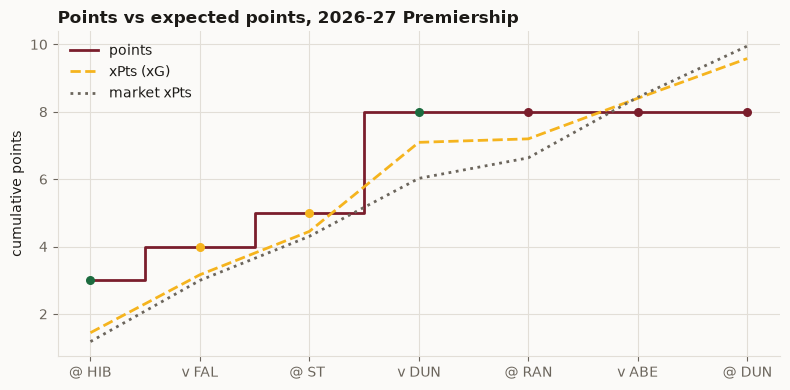

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(1, len(league) + 1)
ax.step(x, league.cum_points, where="mid", color=CLARET, linewidth=2, label="points")
ax.plot(x, league.cum_xpts, color=AMBER, linestyle="--", linewidth=2, label="xPts (xG)")
ax.plot(x, league.cum_market, color=MUTED, linestyle=":", linewidth=2, label="market xPts")
for xi, r in zip(x, league.result):
    ax.scatter([xi], [league.cum_points.iloc[xi - 1]], color=RESULT_COLOURS[r], s=30, zorder=3)
labels = [f"{'v' if h == 'home' else '@'} {o[:3].upper()}" for h, o in zip(league.home_away, league.opponent)]
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("cumulative points")
ax.set_title("Points vs expected points, 2026-27 Premiership", loc="left", fontweight="bold")
ax.legend(loc="upper left")
fig.tight_layout()

In [4]:
summary = season_summary(log, competition="sco.1")
keys = ("games", "points", "ppg", "goals_for", "goals_against", "xg_for", "xg_against", "xg_diff", "xpoints", "form")
{k: summary[k] for k in keys}

{'games': 7,
 'points': 8,
 'ppg': 1.14,
 'goals_for': 9,
 'goals_against': 11,
 'xg_for': 9.52,
 'xg_against': 11.08,
 'xg_diff': -1.56,
 'xpoints': 9.58,
 'form': 'WDDWLLL'}

In [5]:
league.sort_values("pts_minus_xpts")[["date", "opponent", "result", "motherwell_xg", "opponent_xg", "points", "xpts", "pts_minus_xpts"]].round(2)

,date,opponent,result,motherwell_xg,opponent_xg,points,xpts,pts_minus_xpts
5,2026-09-15,Aberdeen,L,0.77,0.92,0,1.20,-1.20
6,2026-09-19,Dundee,L,1.10,1.36,0,1.18,-1.18
1,2026-08-09,Falkirk,D,0.89,0.44,1,1.72,-0.72
2,2026-08-30,St Mirren,D,2.11,2.32,1,1.29,-0.29
4,2026-09-05,Rangers,L,0.51,3.93,0,0.10,-0.10
3,2026-09-02,Dundee United,W,2.14,0.19,3,2.64,0.36
0,2026-08-02,Hibernian,W,2.00,1.92,3,1.44,1.56


## Conclusion

**Finding.** Read the two tables above: the season summary gives total points against total xPts, and the ranked table names the matches where the result diverged most from the xG. Write the finding in a sentence with those numbers once the cells have run; do not paste numbers from memory.

**Limitations.** Seven matches. Vendor xG with an unpublished model. xPts assumes independent Poisson goals, which overstates draws slightly. Market xPts uses closing odds, which already price injuries and form.

**Next step.** Re-run after every round; once the sample passes 15 matches, split home and away and compare with the 2025-26 history (which lacks xG, so use shots on target as the proxy).